# Vegetation Detection — Custom CNN
### Sentinel-2 Imagery · Task 3
**Goal:** Build a Convolutional Neural Network for vegetation detection and compare it against the MLP from Task 2.

**Pipeline:**
- Same data loading as Task 1 & 2
- Custom CNN with Conv → BN → ReLU → MaxPool blocks
- Same evaluation metrics as Task 2 (Accuracy, Precision, Recall, F1)
- Side-by-side comparison table at the end

**Note:** Use Python 3.12.0

In [1]:
import sys
!{sys.executable} -m pip install torch torchvision Pillow numpy matplotlib scikit-learn rasterio --quiet

In [3]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("PyTorch version :", torch.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device          :", DEVICE)

PyTorch version : 2.11.0+cpu
Device          : cpu


## 1 · Configuration
Same paths as Task 1 & 2. Only the model architecture changes.

In [4]:
ROUTE_SAMPLES  = "data/samples"
ROUTE_LABELS   = "data/labels"

NDVI_THRESHOLD = 0.3     # same as Task 2
PATCH_SIZE     = 32      # image patches fed to CNN  (32x32 pixels)
STRIDE         = 8       # stride when extracting patches
LEARNING_RATE  = 1e-3
EPOCHS         = 30
BATCH_SIZE     = 128
TEST_SPLIT     = 0.20

print("Config loaded ✓")

Config loaded ✓


## 2 · Data Loading
Identical to Task 1 & 2 — same normalisation, same NDVI threshold.

In [5]:
def load_pair(img_path, ndvi_path):
    with Image.open(img_path) as im:
        rgb = np.array(im).astype(np.float32)        # (H, W, 3)
    max_val = rgb.max()
    if max_val > 0:
        rgb = rgb / max_val                          # normalise to [0,1]

    with Image.open(ndvi_path) as nm:
        ndvi = np.array(nm).astype(np.float32)       # (H, W)
    if ndvi.max() > 1 or ndvi.min() < -1:
        ndvi = (ndvi - ndvi.min()) / (ndvi.max() - ndvi.min()) * 2 - 1

    mask = (ndvi > NDVI_THRESHOLD).astype(np.int64)  # binary: 0/1
    return rgb, ndvi, mask


def discover_pairs(samples_dir, labels_dir):
    files  = [f for f in os.listdir(samples_dir) if f.endswith(".tiff")]
    paired = [f for f in files
              if os.path.exists(os.path.join(labels_dir,
                                             f.replace("_img_", "_ndvi_")))]
    return [(os.path.join(samples_dir, f),
             os.path.join(labels_dir,  f.replace("_img_", "_ndvi_")))
            for f in sorted(paired)]


pairs = discover_pairs(ROUTE_SAMPLES, ROUTE_LABELS)
print(f"Found {len(pairs)} image pairs")

all_rgb, all_ndvi, all_mask = [], [], []
for img_p, ndvi_p in pairs:
    rgb, ndvi, mask = load_pair(img_p, ndvi_p)
    all_rgb.append(rgb); all_ndvi.append(ndvi); all_mask.append(mask)
    print(f"  {os.path.basename(img_p)[-20:]}  shape={rgb.shape}  "
          f"veg={mask.mean()*100:.1f}%")

print("\nData loaded ✓")

Found 3 image pairs
  3157.SAFE_img_0.tiff  shape=(256, 256, 3)  veg=69.6%
  3157.SAFE_img_1.tiff  shape=(256, 256, 3)  veg=56.0%
  3157.SAFE_img_2.tiff  shape=(256, 256, 3)  veg=43.3%

Data loaded ✓


## 3 · Patch Dataset
The CNN takes **32×32 image patches** as input (instead of flattened pixels like Task 2).
Each patch keeps its spatial structure  that's what the convolutional layers exploit.

In [6]:
class PatchDataset(Dataset):
    """
    Slides a PATCH_SIZE x PATCH_SIZE window over every image.
    Returns (patch_tensor, label) where:
      patch_tensor : float32 tensor of shape (3, PATCH_SIZE, PATCH_SIZE)
      label        : int64  — majority class in the patch centre region
    """
    def __init__(self, rgb_list, mask_list, patch_size, stride):
        self.samples = []
        half = patch_size // 2

        for rgb, mask in zip(rgb_list, mask_list):
            H, W = mask.shape
            for y in range(half, H - half, stride):
                for x in range(half, W - half, stride):
                    patch = rgb[y-half:y+half, x-half:x+half, :]  # (P,P,3)
                    label = int(mask[y, x])                        # centre pixel
                    # tensor shape: (3, P, P)  — channels first for PyTorch
                    self.samples.append(
                        (torch.tensor(patch.transpose(2, 0, 1),
                                      dtype=torch.float32), label)
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


dataset    = PatchDataset(all_rgb, all_mask, PATCH_SIZE, STRIDE)
n_total    = len(dataset)
n_test     = int(n_total * TEST_SPLIT)
n_train    = n_total - n_test

train_ds, test_ds = torch.utils.data.random_split(
    dataset, [n_train, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Total patches : {n_total:,}")
print(f"Train         : {n_train:,}")
print(f"Test          : {n_test:,}")

# class balancing — same technique as Task 2
train_labels = [dataset[i][1] for i in train_ds.indices]
n0 = train_labels.count(0)
n1 = train_labels.count(1)
weights  = [1/n0 if l == 0 else 1/n1 for l in train_labels]
sampler  = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nClass balance in train — non-veg: {n0:,}  veg: {n1:,}")
print("Dataset ready ✓")

Total patches : 2,352
Train         : 1,882
Test          : 470

Class balance in train — non-veg: 780  veg: 1,102
Dataset ready ✓


## 4 · CNN Architecture

```
INPUT (3 × 32 × 32)
  ↓
Conv2d(3→32, 3×3, pad=1) → BatchNorm → ReLU   output: 32×32×32
  ↓
MaxPool2d(2×2)                                  output: 16×16×32
  ↓
Conv2d(32→64, 3×3, pad=1) → BatchNorm → ReLU  output: 16×16×64
  ↓
MaxPool2d(2×2)                                  output: 8×8×64
  ↓
Conv2d(64→128, 3×3, pad=1) → BatchNorm → ReLU output: 8×8×128
  ↓
GlobalAvgPool                                   output: 128
  ↓
Dropout(0.4)
  ↓
Linear(128 → 2) → Softmax
```

**Why this architecture:**
- 3 conv blocks progressively detect edges → textures → vegetation patterns
- BatchNorm after every conv stabilises training (no exploding/vanishing gradients)
- GlobalAvgPool replaces Flatten+FC — fewer parameters, less overfitting
- Dropout(0.4) regularises the final layer

In [7]:
class VegetationCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1 — detects edges and colour gradients
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 channels in, 32 out
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # 32x32 → 16x16
        )

        # Block 2 — detects textures and simple shapes
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # 16x16 → 8x8
        )

        # Block 3 — detects vegetation patterns
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        # Classifier head
        self.gap     = nn.AdaptiveAvgPool2d(1)   # Global Average Pool → (128, 1, 1)
        self.dropout = nn.Dropout(0.4)
        self.fc      = nn.Linear(128, 2)         # 2 classes: veg / non-veg

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).squeeze(-1).squeeze(-1)  # (B, 128)
        x = self.dropout(x)
        return self.fc(x)                        # (B, 2) logits


model = VegetationCNN().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"CNN architecture ready")
print(f"Trainable parameters: {total_params:,}")
print(model)

CNN architecture ready
Trainable parameters: 93,954
VegetationCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (gap): AdaptiveAvgPool2d(output_size=1)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=Tr

## 5 · Training

In [8]:
# weighted cross-entropy to handle class imbalance
class_counts  = torch.tensor([n0, n1], dtype=torch.float32)
class_weights = (1.0 / class_counts).to(DEVICE)
criterion     = nn.CrossEntropyLoss(weight=class_weights)

optimizer  = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"loss": [], "train_acc": [], "test_acc": []}

print(f"{'Epoch':>6}  {'Loss':>8}  {'Train Acc':>10}  {'Test Acc':>9}")
print("-" * 42)

for epoch in range(1, EPOCHS + 1):

    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()       # backpropagation
        optimizer.step()      # gradient descent
        epoch_loss += loss.item() * len(y_batch)

    scheduler.step()
    avg_loss = epoch_loss / len(train_ds)

    if epoch % 5 == 0 or epoch == 1:
        model.eval()
        def batch_acc(loader):
            correct = total = 0
            with torch.no_grad():
                for Xb, yb in loader:
                    preds    = model(Xb.to(DEVICE)).argmax(1).cpu()
                    correct += (preds == yb).sum().item()
                    total   += len(yb)
            return correct / total

        tr_acc = batch_acc(train_loader)
        te_acc = batch_acc(test_loader)
        history["loss"].append(avg_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)
        print(f"{epoch:>6}  {avg_loss:>8.4f}  {tr_acc*100:>9.2f}%  {te_acc*100:>9.2f}%")

print("\nTraining complete ✓")

 Epoch      Loss   Train Acc   Test Acc
------------------------------------------
     1    0.4524      78.00%      82.55%
     5    0.3164      85.33%      81.70%
    10    0.2877      87.99%      87.45%
    15    0.2846      85.55%      84.47%
    20    0.2343      85.97%      81.06%
    25    0.2491      90.97%      86.81%
    30    0.2411      89.37%      87.45%

Training complete ✓


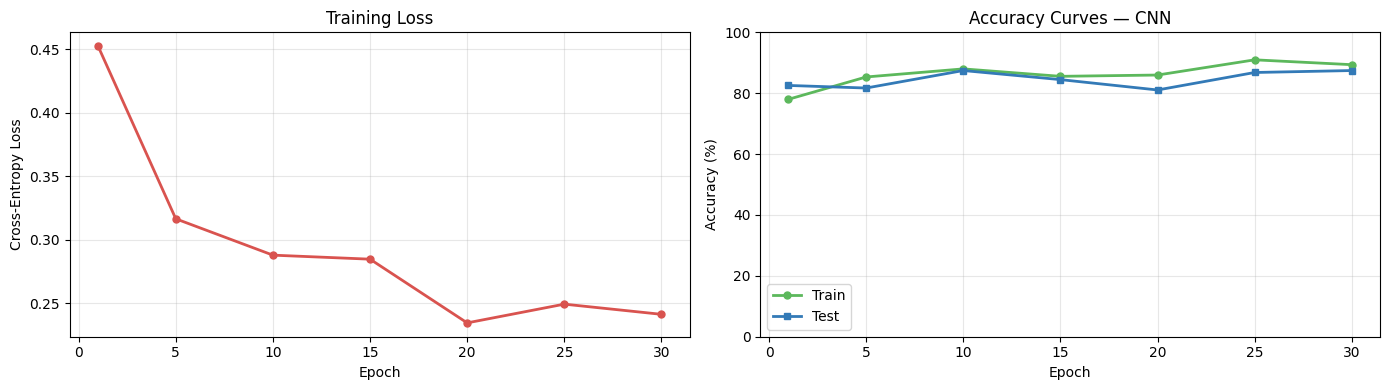

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

n = len(history["loss"])
epochs_logged = ([1] + list(range(5, EPOCHS+1, 5)))[:n]

ax1.plot(epochs_logged, history["loss"],
         color="#d9534f", linewidth=2, marker="o", markersize=5)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Training Loss"); ax1.grid(alpha=0.3)

ax2.plot(epochs_logged, [v*100 for v in history["train_acc"]],
         label="Train", color="#5cb85c", linewidth=2, marker="o", markersize=5)
ax2.plot(epochs_logged, [v*100 for v in history["test_acc"]],
         label="Test",  color="#337ab7", linewidth=2, marker="s", markersize=5)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy Curves — CNN"); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_ylim([0, 100])

plt.tight_layout()
plt.show()

## 6 · Evaluation

  Custom CNN — Test Set Results
  Accuracy           : 87.45%
  Precision (macro)  : 87.78%
  Recall    (macro)  : 86.29%
  F1-Score  (macro)  : 86.84%

                precision    recall  f1-score   support

Non-Vegetation      0.891     0.795     0.840       195
    Vegetation      0.865     0.931     0.897       275

      accuracy                          0.874       470
     macro avg      0.878     0.863     0.868       470
  weighted avg      0.876     0.874     0.873       470



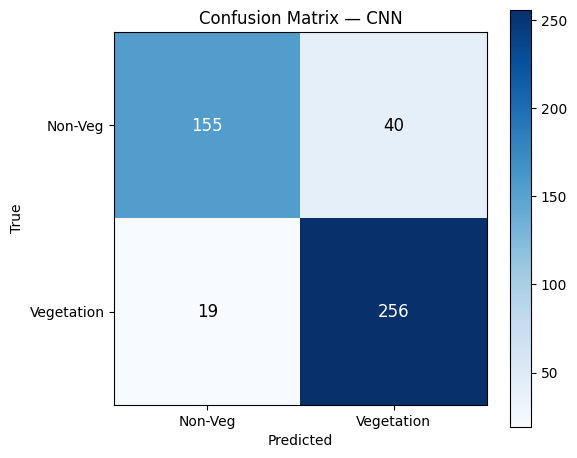

In [10]:
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds = model(Xb.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

cnn_acc  = accuracy_score(all_true, all_preds)
cnn_prec = precision_score(all_true, all_preds, average="macro", zero_division=0)
cnn_rec  = recall_score(all_true, all_preds, average="macro", zero_division=0)
cnn_f1   = f1_score(all_true, all_preds, average="macro", zero_division=0)

print("=" * 50)
print("  Custom CNN — Test Set Results")
print("=" * 50)
print(f"  Accuracy           : {cnn_acc*100:.2f}%")
print(f"  Precision (macro)  : {cnn_prec*100:.2f}%")
print(f"  Recall    (macro)  : {cnn_rec*100:.2f}%")
print(f"  F1-Score  (macro)  : {cnn_f1*100:.2f}%")
print()
print(classification_report(all_true, all_preds,
                             target_names=["Non-Vegetation", "Vegetation"],
                             digits=3))

cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Non-Veg", "Vegetation"])
ax.set_yticklabels(["Non-Veg", "Vegetation"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — CNN")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=12)
plt.tight_layout(); plt.show()

## 7 · Visualise Predictions

Predicting image 0... done
Predicting image 1... done
Predicting image 2... done


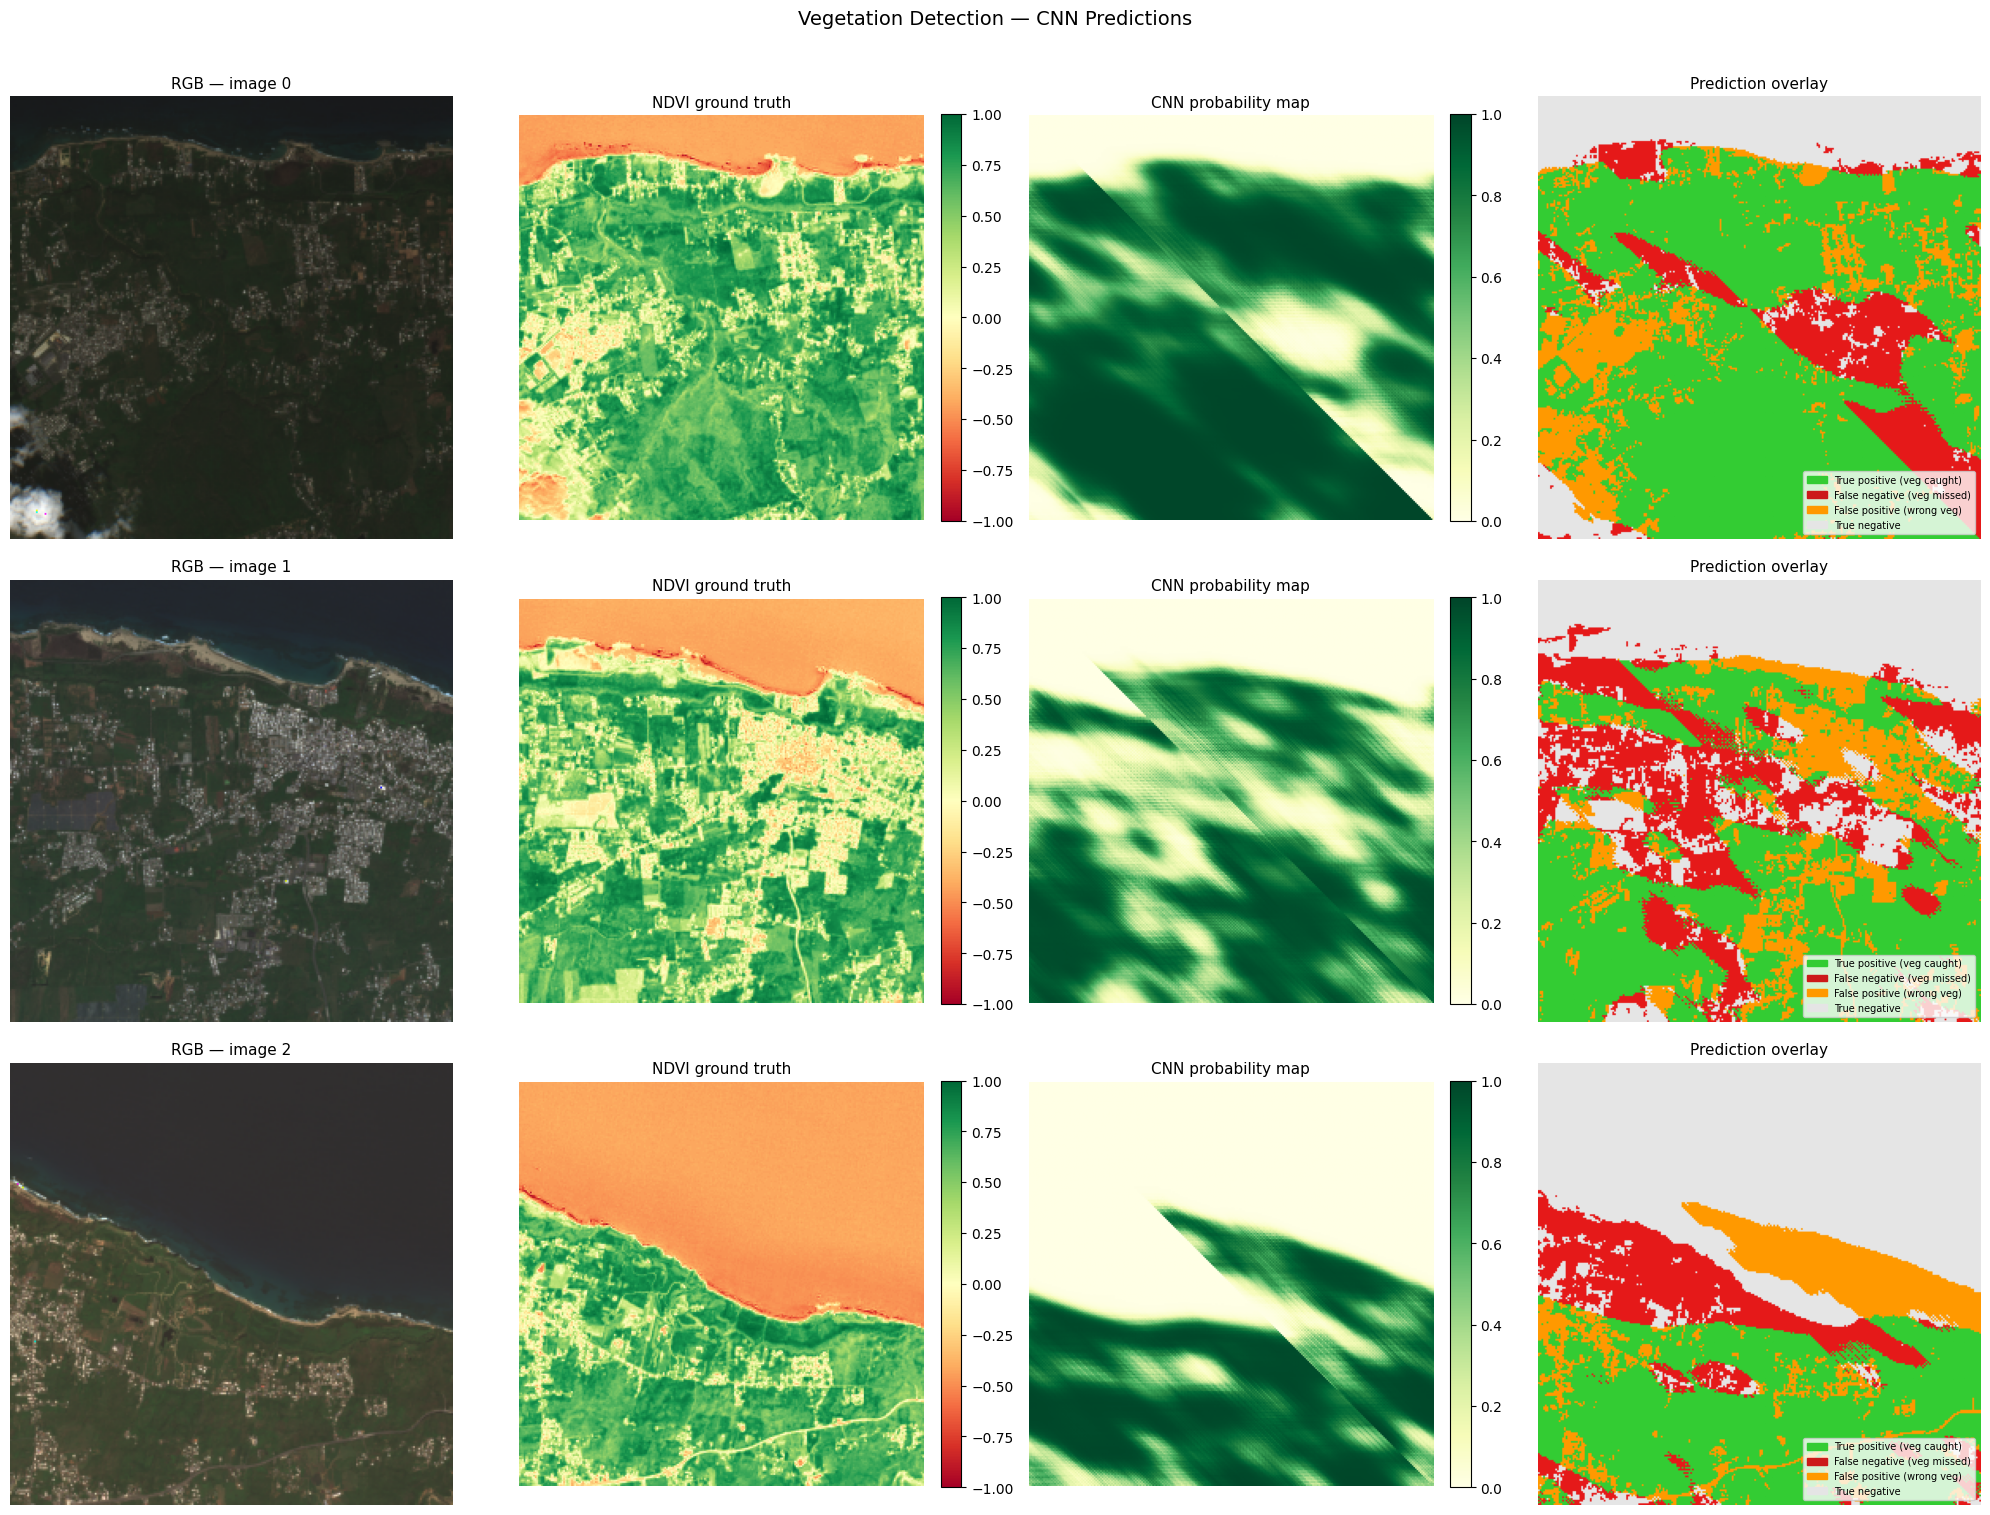

In [13]:
def predict_full_image(model, rgb, patch_size=PATCH_SIZE):
    """
    Fast batch prediction using F.unfold — extracts all patches at once
    instead of looping pixel by pixel.
    """
    model.eval()
    H, W = rgb.shape[:2]
    half = patch_size // 2
    prob_map = np.zeros((H, W), dtype=np.float32)

    # convert image to tensor (1, 3, H, W)
    img_tensor = torch.tensor(rgb.transpose(2, 0, 1),
                               dtype=torch.float32).unsqueeze(0)

    # pad so every pixel gets a patch
    padded = F.pad(img_tensor, (half, half, half, half), mode="reflect")

    # unfold extracts all patches at once → (1, 3*P*P, H*W)
    patches = F.unfold(padded, kernel_size=patch_size)  # (1, C*P*P, H*W)
    patches = patches.squeeze(0).T                      # (H*W, C*P*P)
    patches = patches.view(-1, 3, patch_size, patch_size)  # (H*W, 3, P, P)

    # run through model in batches of 512
    INFER_BATCH = 512
    all_probs = []
    with torch.no_grad():
        for start in range(0, len(patches), INFER_BATCH):
            batch  = patches[start:start+INFER_BATCH].to(DEVICE)
            logits = model(batch)
            probs  = torch.softmax(logits, dim=1)[:, 1].cpu()
            all_probs.append(probs)

    prob_map = torch.cat(all_probs).numpy()[:H*W].reshape(H, W)
    return prob_map


n_imgs = len(all_rgb)
fig, axes = plt.subplots(n_imgs, 4, figsize=(20, n_imgs * 5))
if n_imgs == 1: axes = axes[np.newaxis, :]

for i, (rgb, ndvi, mask) in enumerate(zip(all_rgb, all_ndvi, all_mask)):
    print(f"Predicting image {i}...", end=" ", flush=True)
    prob_map  = predict_full_image(model, rgb)
    pred_mask = (prob_map > 0.5).astype(int)
    print("done")

    axes[i,0].imshow(rgb)
    axes[i,0].set_title(f"RGB — image {i}", fontsize=11)
    axes[i,0].axis("off")

    im1 = axes[i,1].imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
    axes[i,1].set_title("NDVI ground truth", fontsize=11)
    axes[i,1].axis("off")
    plt.colorbar(im1, ax=axes[i,1], fraction=0.046, pad=0.04)

    im2 = axes[i,2].imshow(prob_map, cmap="YlGn", vmin=0, vmax=1)
    axes[i,2].set_title("CNN probability map", fontsize=11)
    axes[i,2].axis("off")
    plt.colorbar(im2, ax=axes[i,2], fraction=0.046, pad=0.04)

    overlay = np.zeros((*mask.shape, 3), dtype=np.float32)
    overlay[(mask==1)&(pred_mask==1)] = [0.2, 0.8, 0.2]
    overlay[(mask==1)&(pred_mask==0)] = [0.9, 0.1, 0.1]
    overlay[(mask==0)&(pred_mask==1)] = [1.0, 0.6, 0.0]
    overlay[(mask==0)&(pred_mask==0)] = [0.9, 0.9, 0.9]
    axes[i,3].imshow(overlay)
    axes[i,3].set_title("Prediction overlay", fontsize=11)
    axes[i,3].axis("off")
    tp = mpatches.Patch(color="#33cc33", label="True positive (veg caught)")
    fn = mpatches.Patch(color="#cc1a1a", label="False negative (veg missed)")
    fp = mpatches.Patch(color="#ff9900", label="False positive (wrong veg)")
    tn = mpatches.Patch(color="#e5e5e5", label="True negative")
    axes[i,3].legend(handles=[tp,fn,fp,tn], loc="lower right", fontsize=7)

plt.suptitle("Vegetation Detection — CNN Predictions", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


## 8 · Comparison — Task 2 MLP vs Task 3 CNN
Enter the Task 2 results manually from your saved output, then run this cell.

  Metric                    Task 2 MLP      Task 3 CNN
  Accuracy                      92.00%           87.45%   ← MLP wins
  Precision                     92.62%           87.78%   ← MLP wins
  Recall                        93.17%           86.29%   ← MLP wins
  F1-Score                      92.21%           86.84%   ← MLP wins


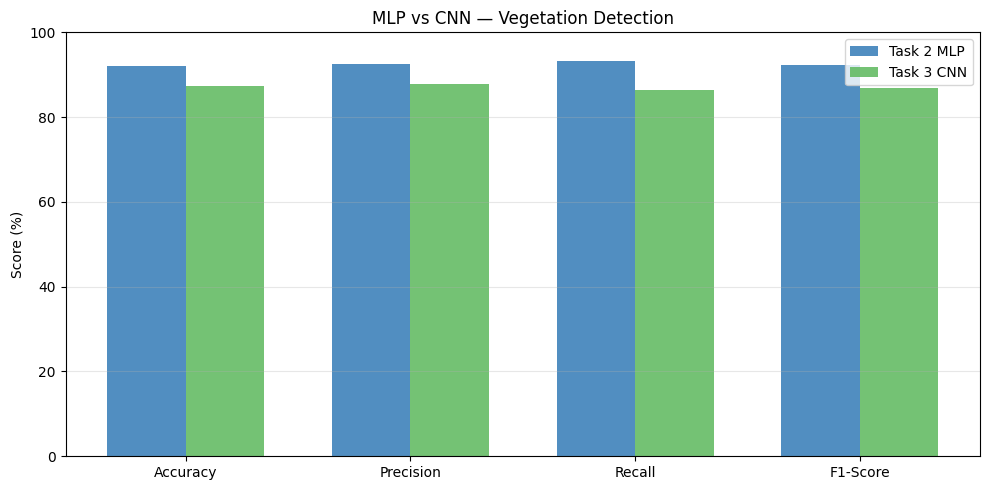

In [16]:
# ── Paste your Task 2 results here ───────────────────────────────────────────
mlp_acc  = 0.92   # replace with your Task 2 accuracy  (0.0 – 1.0)
mlp_prec = 0.9262   # replace with Task 2 precision
mlp_rec  = 0.9317   # replace with Task 2 recall
mlp_f1   = 0.9221   # replace with Task 2 F1

# ── Comparison table ──────────────────────────────────────────────────────────
print("=" * 62)
print(f"  {'Metric':<20} {'Task 2 MLP':>15} {'Task 3 CNN':>15}")
print("=" * 62)
for metric, mlp_val, cnn_val in [
    ("Accuracy",  mlp_acc,  cnn_acc),
    ("Precision", mlp_prec, cnn_prec),
    ("Recall",    mlp_rec,  cnn_rec),
    ("F1-Score",  mlp_f1,   cnn_f1),
]:
    better = "← CNN wins" if cnn_val > mlp_val else ("← MLP wins" if mlp_val > cnn_val else "tie")
    print(f"  {metric:<20} {mlp_val*100:>14.2f}%  {cnn_val*100:>14.2f}%   {better}")
print("=" * 62)

# ── Bar chart ─────────────────────────────────────────────────────────────────
metrics    = ["Accuracy", "Precision", "Recall", "F1-Score"]
mlp_scores = [mlp_acc, mlp_prec, mlp_rec, mlp_f1]
cnn_scores = [cnn_acc, cnn_prec, cnn_rec, cnn_f1]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, [v*100 for v in mlp_scores], width,
       label="Task 2 MLP", color="#337ab7", alpha=0.85)
ax.bar(x + width/2, [v*100 for v in cnn_scores], width,
       label="Task 3 CNN", color="#5cb85c", alpha=0.85)

ax.set_ylabel("Score (%)")
ax.set_title("MLP vs CNN — Vegetation Detection")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim([0, 100])
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 9 · Save the Model

In [ ]:
torch.save({
    "model_state" : model.state_dict(),
    "patch_size"  : PATCH_SIZE,
    "threshold"   : NDVI_THRESHOLD,
}, "vegetation_cnn.pt")

print("Model saved → vegetation_cnn.pt")
print("\nTo reload:")
print("  ckpt  = torch.load('vegetation_cnn.pt')")
print("  model = VegetationCNN()")
print("  model.load_state_dict(ckpt['model_state'])")